PART (a): 绘制树状图

Dealing SINGLE linkage...


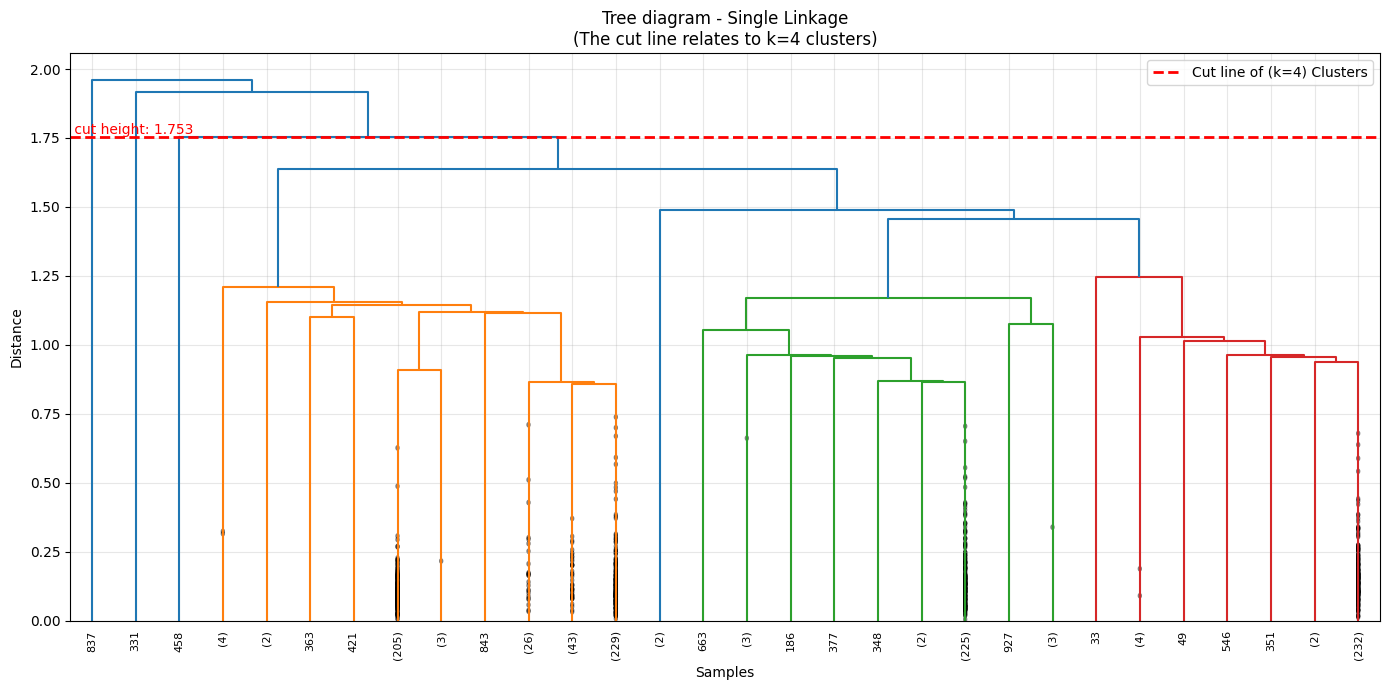


Dealing COMPLETE linkage...


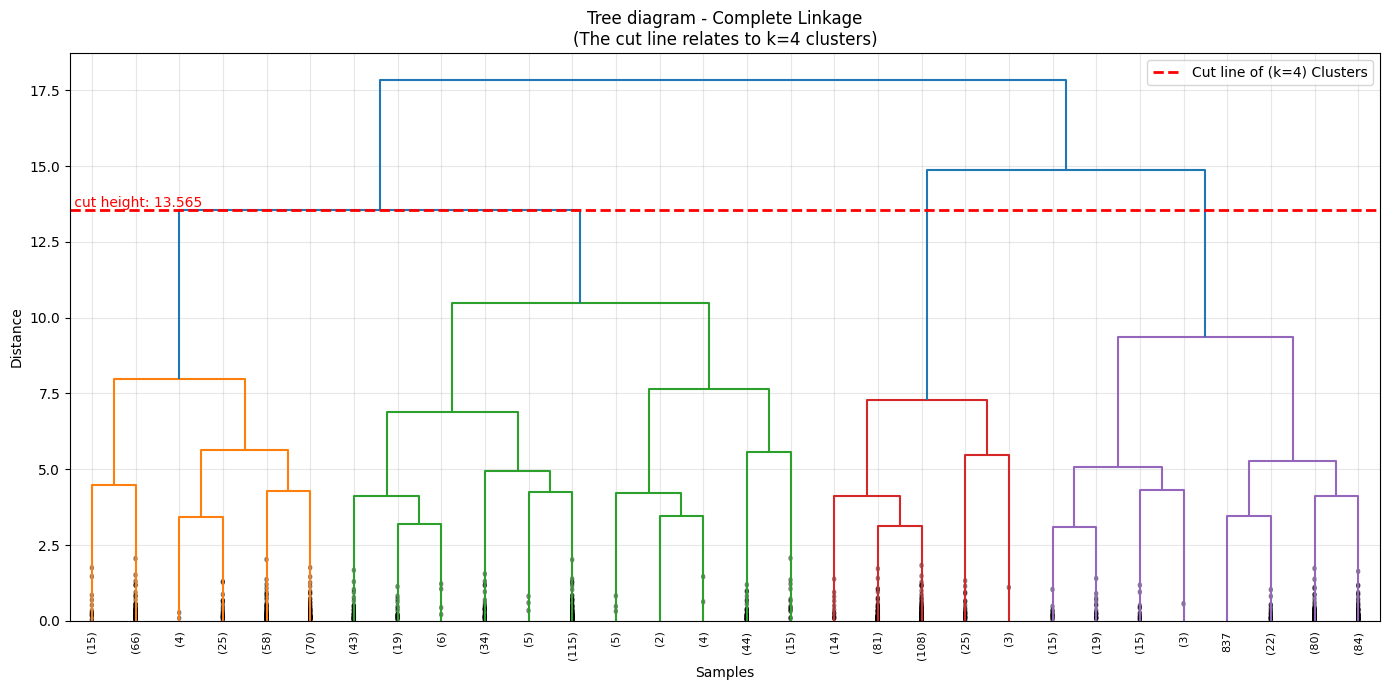


Dealing AVERAGE linkage...


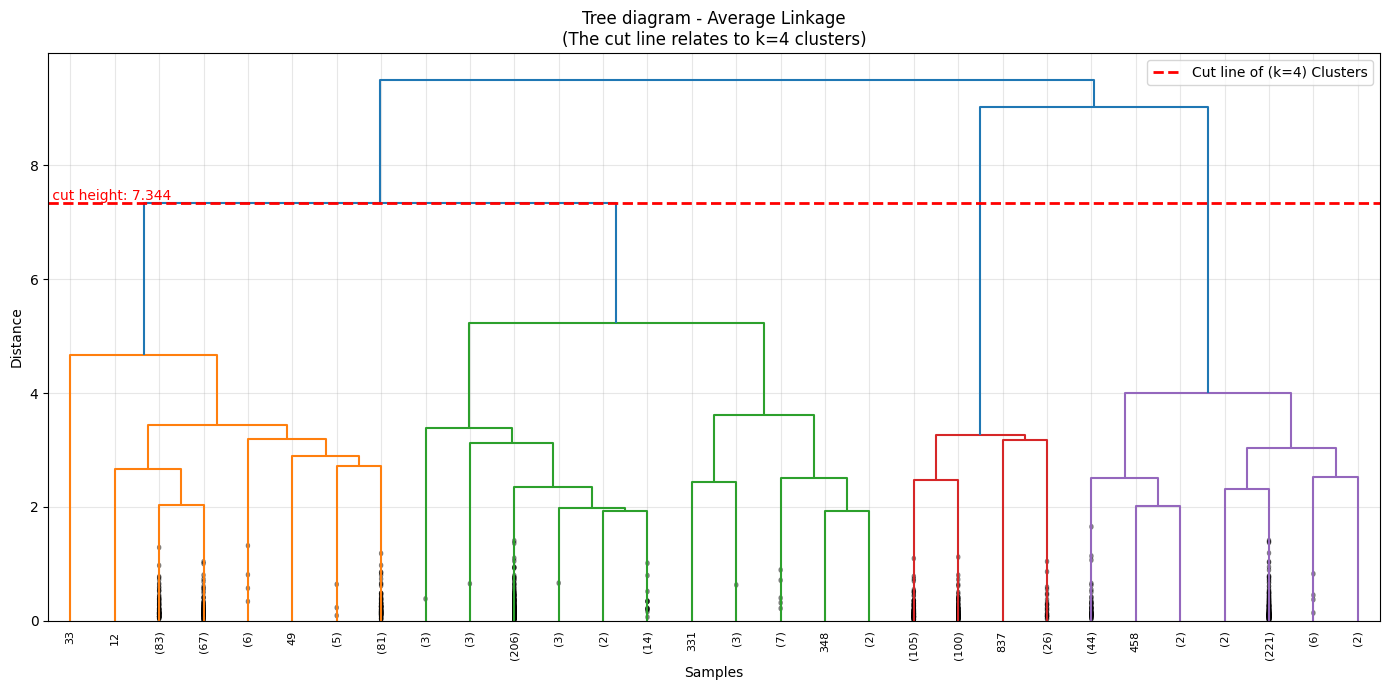

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

data = pd.read_csv(r"C:\Users\Isaac\Desktop\文件管理\Homework\HW3_q4_data.csv")
X = data.values

def part_a_dendrogram(X, linkage_method, k=4):
    """
    Part (a): 绘制树状图并标出产生k个聚类的切割线
    
    参数:
    X: 数据矩阵
    linkage_method: 'single', 'complete', 或 'average'
    k: 期望的聚类数量
    """
    # 执行层次聚类
    Z = linkage(X, method=linkage_method)
    
    # 创建图形
    plt.figure(figsize=(14, 7))
    
    # 绘制树状图
    dendrogram(Z, truncate_mode='lastp', leaf_rotation=90,leaf_font_size=8, show_contracted=True)
    
    # 计算切割高度（产生k个聚类的高度）
    # 方法：找到第(k-1)次合并的高度
    if k < len(Z) + 1:
        # 获取最后k-1次合并的距离
        cut_height = Z[-(k-1), 2]
        
        # 添加水平切割线
        plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2, label=f'Cut line of (k={k}) Clusters')
        
        # 在图上标注
        plt.text(0.02, cut_height, f' cut height: {cut_height:.3f}', verticalalignment='bottom', fontsize=10, color='red')
    
    plt.title(f"Tree diagram - {linkage_method.capitalize()} Linkage\n(The cut line relates to k={k} clusters)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return Z

# 运行Part A - 测试三种链接方法
print("PART (a): 绘制树状图")

linkage_methods = ['single', 'complete', 'average']
for method in linkage_methods:
    print(f"\nDealing {method.upper()} linkage...")
    Z = part_a_dendrogram(X, method, k=4)

PART (b): 分配聚类标签并创建散点图


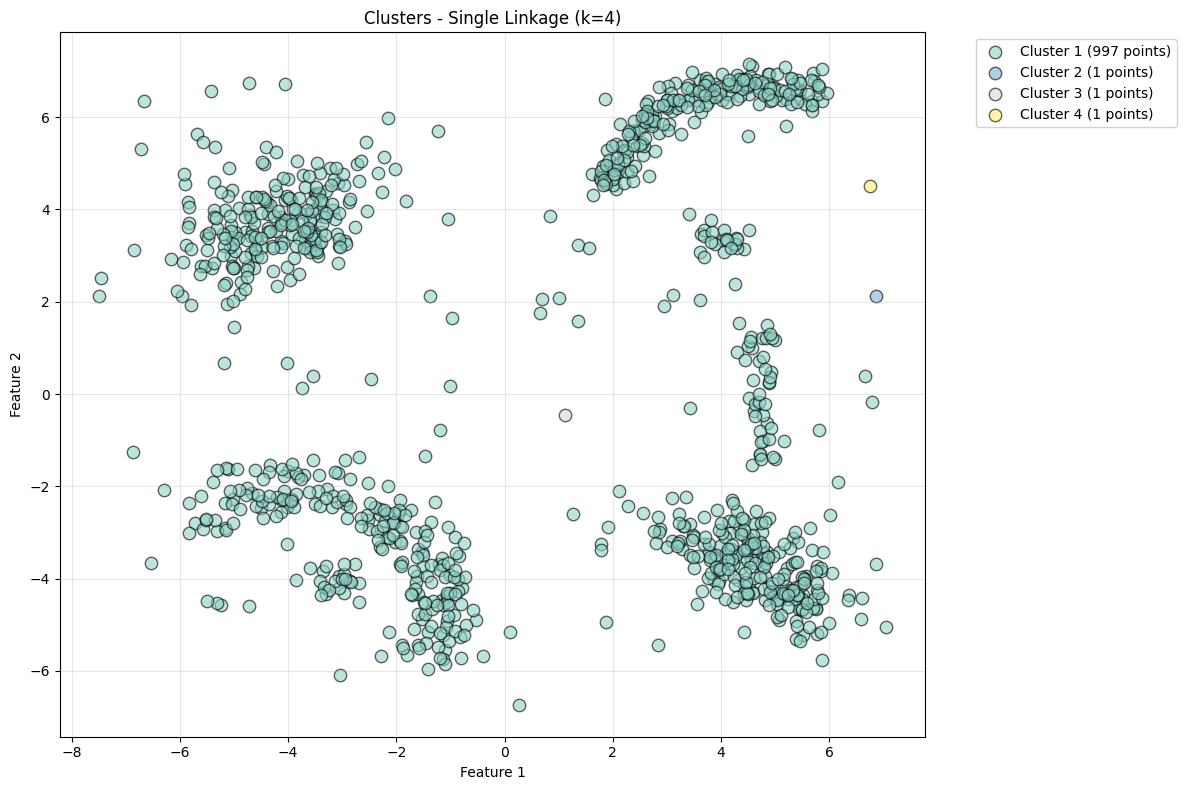

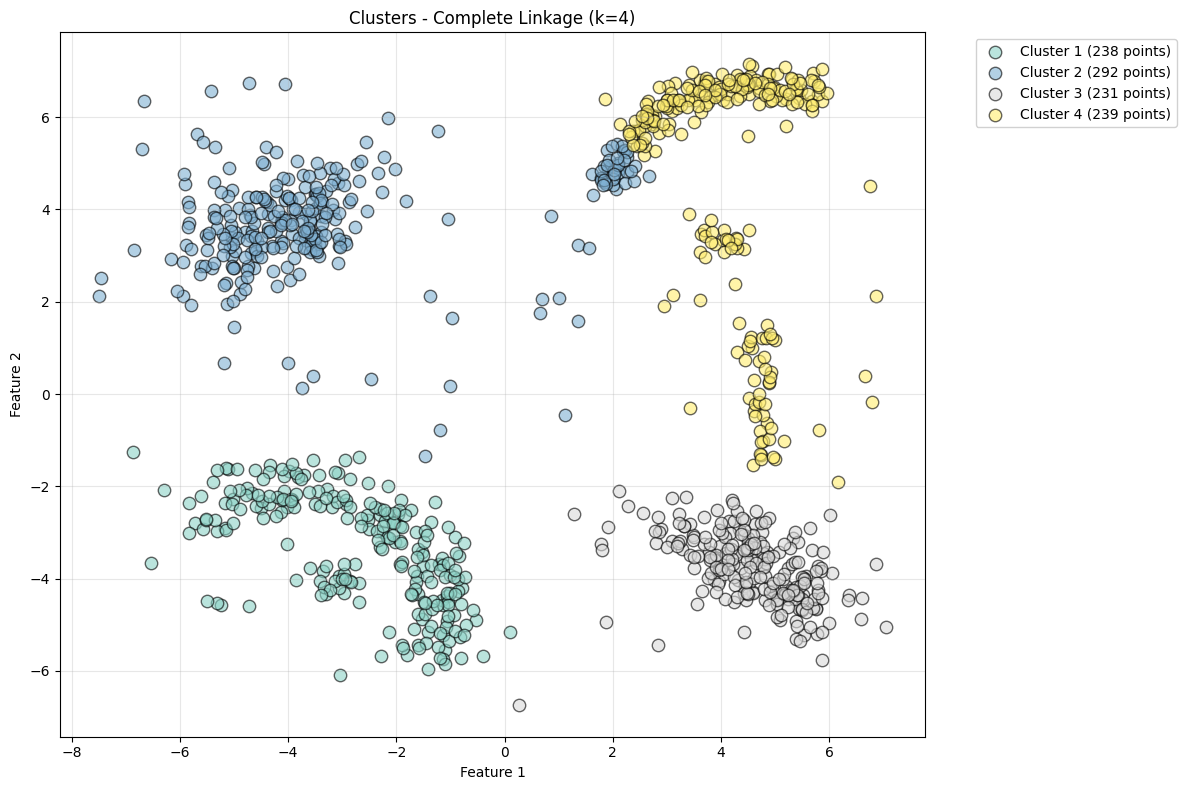

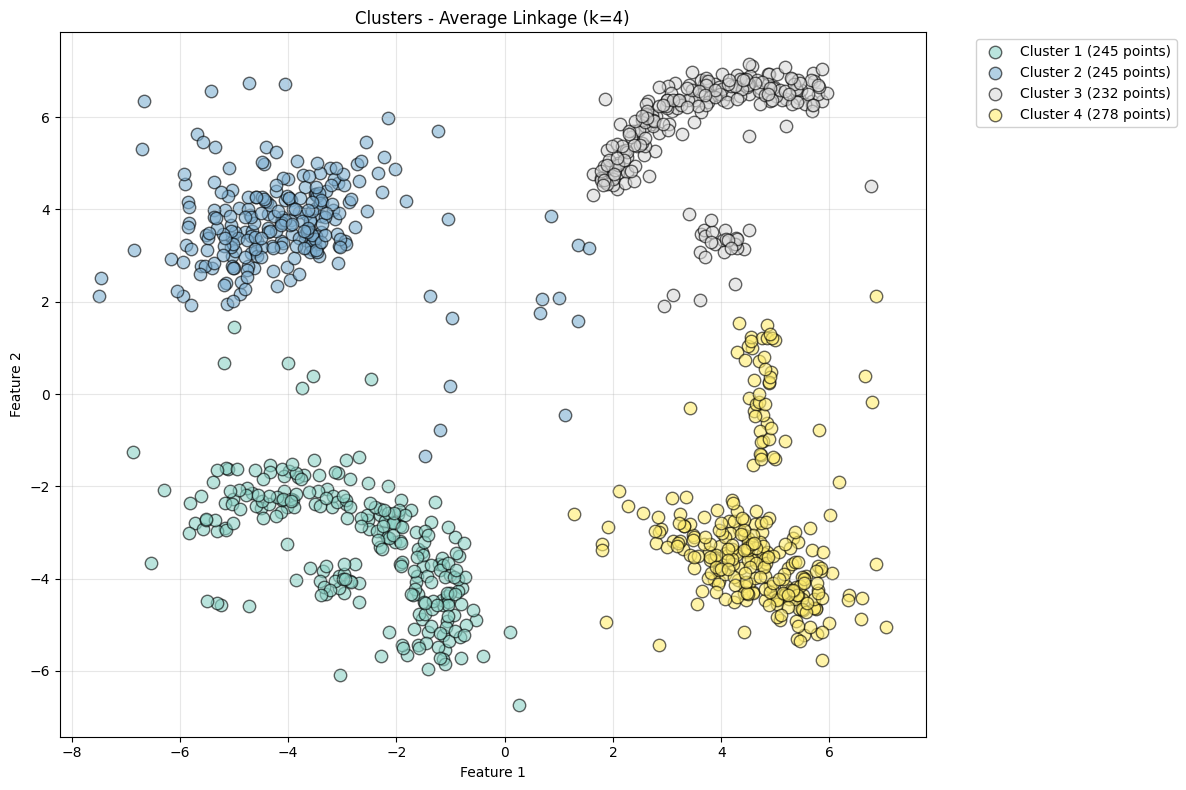

In [23]:
def part_b_cluster_scatter(X, linkage_method, k=4):
    """
    Part (b): 分配聚类标签并创建彩色散点图
    
    参数:
    X: 数据矩阵
    linkage_method: 'single', 'complete', 或 'average'
    k: 期望的聚类数量
    
    返回:
    cluster_labels: 每个点的聚类标签
    """
    # 执行层次聚类
    Z = linkage(X, method=linkage_method)
    
    # 切割树状图得到k个聚类
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    
    # 创建散点图
    plt.figure(figsize=(12, 8))
    
    # 获取唯一的聚类标签
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    
    # 使用颜色映射
    colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))
    
    # 为每个聚类绘制点
    for i, cluster in enumerate(unique_clusters):
        mask = cluster_labels == cluster
        points = X[mask]
        
        plt.scatter(points[:, 0], points[:, 1], c=[colors[i]],label=f'Cluster {cluster} ({len(points)} points)',
                   alpha=0.6, s=80, edgecolors='black', linewidth=1)
    
    plt.title(f'Clusters - {linkage_method.capitalize()} Linkage (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return cluster_labels, Z

# 运行Part B - 测试三种链接方法
print("PART (b): 分配聚类标签并创建散点图")

all_labels = {}  # 存储所有方法的标签结果

for method in linkage_methods:
    
    labels, Z = part_b_cluster_scatter(X, method, k=4)
    all_labels[method] = labels